# Signature kernels with `ksig` — toy examples

[`ksig`](https://github.com/tgcsaba/KSig) computes **signature kernels** for
sequential data: kernels between *paths* rather than between points. The kernel
between two sequences is built from the (truncated) path signature lifted into an
RKHS, so it sees the *order* of what happened, not just the marginal values.

This notebook is a hands-on tour on toy data:

1. Building a Gram matrix and reading its block structure
2. The kernel API — cross-Gram, diagonal, `n_levels`, `order`, `normalize`, static kernels
3. Preprocessing — augmentation and ragged (variable-length) sequences
4. Reparameterisation invariance, the property that makes signatures useful
5. Classification with a precomputed-kernel SVC
6. Low-rank signature *features* for scaling past a few thousand sequences
7. The rest of the kernel zoo — PDE kernel, global alignment kernel, random warping series

**`ksig` is GPU-only.** Everything runs through `cupy`; inputs can be `numpy`
arrays (they are moved to the GPU internally) and results come back as `numpy`
unless you pass `return_on_gpu=True`. The environment is defined in
`pixi.toml` — run this notebook with `pixi run lab`.

In [1]:
import time

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist

import ksig
from ksig.preprocessing import SequenceAugmentor, SequenceTabulator
from ksig.projections import TensorizedRandomProjection
from ksig.static.features import RandomFourierFeatures
from ksig.static.kernels import LinearKernel, RBFKernel

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC, LinearSVC

dev = cp.cuda.Device(0)
print(f"cupy {cp.__version__} | compute capability {dev.compute_capability} | "
      f"free/total memory {[m / 2**30 for m in dev.mem_info]} GiB")

# Plot styling: one categorical hue per series, recessive axes.
BLUE, ORANGE, AQUA, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "axes.edgecolor": GRID,
    "axes.labelcolor": "#52514e",
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(0)

cupy 14.1.1 | compute capability 120 | free/total memory [29.7847900390625, 31.325439453125] GiB


## 1. A first Gram matrix

Toy dataset A: 2D loops that differ only in **orientation** — traversed
counter-clockwise or clockwise — with random radius, random starting phase and
observation noise. The two classes have the same point cloud; only the order in
which the points are visited differs. That is exactly the kind of signal a
signature kernel is built to see (it lives in the level-2 term, the Lévy area).

X.shape = (n_sequences, length, n_channels) = (40, 50, 2)


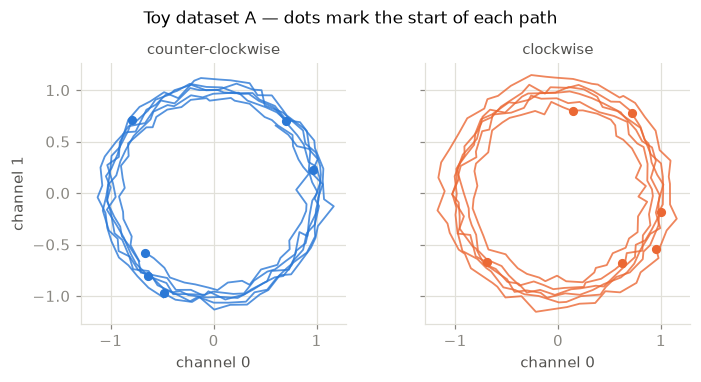

In [2]:
def loops(n, length=50, sign=+1, noise=0.03, rng=rng):
    """`n` noisy 2D loops; `sign=+1` counter-clockwise, `sign=-1` clockwise."""
    t = np.linspace(0, 2 * np.pi, length)
    radius = 1.0 + 0.15 * rng.standard_normal((n, 1))
    phase = rng.uniform(0, 2 * np.pi, (n, 1))
    x = radius * np.cos(t[None] + phase)
    y = sign * radius * np.sin(t[None] + phase)
    paths = np.stack([x, y], axis=-1)
    return paths + noise * rng.standard_normal(paths.shape)


X = np.concatenate([loops(20, sign=+1), loops(20, sign=-1)])
y = np.concatenate([np.zeros(20), np.ones(20)])
print("X.shape = (n_sequences, length, n_channels) =", X.shape)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.4), sharex=True, sharey=True)
for ax, cls, color, name in zip(axes, [0, 1], [BLUE, ORANGE],
                                ["counter-clockwise", "clockwise"]):
    for path in X[y == cls][:6]:
        ax.plot(path[:, 0], path[:, 1], color=color, lw=1.2, alpha=0.8)
        ax.plot(*path[0], "o", ms=5, color=color)
    ax.set_title(name, color="#52514e", fontsize=10)
    ax.set_xlabel("channel 0")
    ax.set_aspect("equal")
axes[0].set_ylabel("channel 1")
fig.suptitle("Toy dataset A — dots mark the start of each path", fontsize=11)
fig.tight_layout()

A kernel object is callable: `kernel(X)` returns the Gram matrix, `kernel(X, Y)`
the cross-Gram. Sequences are `[n, length, n_channels]`. The comparison baseline
is a plain RBF kernel applied to the *flattened* sequences — a static kernel that
treats a path as a long vector of coordinates.

Gram shapes: (40, 40) (40, 40) | returned as ndarray


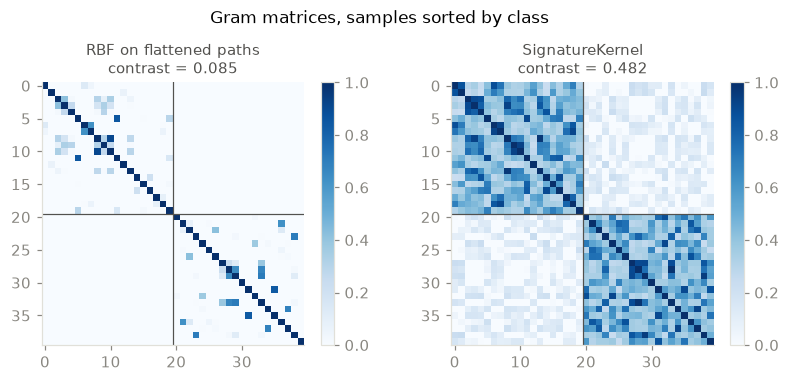

In [3]:
sig_kernel = ksig.kernels.SignatureKernel(n_levels=5, static_kernel=RBFKernel(bandwidth=1.0))
flat_kernel = RBFKernel(bandwidth=1.0)  # static kernels flatten the time axis

K_sig = sig_kernel(X)
K_flat = flat_kernel(X)
print("Gram shapes:", K_sig.shape, K_flat.shape, "| returned as", type(K_sig).__name__)


def block_contrast(K, y):
    """Mean within-class similarity minus mean between-class similarity."""
    within = np.mean([K[np.ix_(y == c, y == c)].mean() for c in np.unique(y)])
    between = K[np.ix_(y == 0, y == 1)].mean()
    return within - between


fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.4))
for ax, K, name in zip(axes, [K_flat, K_sig], ["RBF on flattened paths", "SignatureKernel"]):
    im = ax.imshow(K, cmap="Blues", vmin=0, vmax=1)
    ax.axhline(19.5, color="#52514e", lw=0.8)
    ax.axvline(19.5, color="#52514e", lw=0.8)
    ax.set_title(f"{name}\ncontrast = {block_contrast(K, y):.3f}", fontsize=10, color="#52514e")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Gram matrices, samples sorted by class", fontsize=11)
fig.tight_layout()

The signature Gram matrix shows two clear diagonal blocks; the flat RBF kernel is
close to the identity — with `bandwidth=1` every pair of 100-dimensional flattened
paths is far apart, so it carries almost no structure.

## 2. The kernel API

Every kernel in `ksig` inherits the same call signature:

```python
kernel(X)                      # Gram matrix K(X, X), shape [n, n]
kernel(X, Y)                   # cross-Gram K(X, Y),  shape [n_X, n_Y]
kernel(X, diag=True)           # just the diagonal,   shape [n]
kernel(X, return_on_gpu=True)  # keep the result as a cupy array
```

In [4]:
print("cross-Gram :", sig_kernel(X[:5], X[20:24]).shape)
print("diagonal   :", sig_kernel(X[:5], diag=True))

unnormalized = ksig.kernels.SignatureKernel(n_levels=5, normalize=False)
print("diagonal without normalize:", unnormalized(X[:5], diag=True).round(2))

K_gpu = sig_kernel(X, return_on_gpu=True)
print("on GPU     :", type(K_gpu).__name__, K_gpu.dtype)

cross-Gram : (5, 4)
diagonal   : [1. 1. 1. 1. 1.]
diagonal without normalize: [36.93 31.58 48.55 38.08 24.97]
on GPU     : ndarray float64


The main hyperparameters:

| argument | meaning |
| --- | --- |
| `n_levels` | signature truncation level — how many orders of interaction between channels are kept |
| `order` | embedding order of the low-rank algorithm (`order=1` is cheapest, `order>=n_levels` is exact) |
| `difference` | take increments of the lifted sequences (leave `True`) |
| `normalize` | scale to unit norm in feature space, so `K(x, x) = 1` |
| `static_kernel` | the kernel applied pointwise before lifting (`RBFKernel`, `LinearKernel`, `Matern*`, ...) |

`n_levels=1` only sees the total increment of the path, which for a closed loop is
~0 — so it cannot tell the classes apart. Level 2 introduces the Lévy area and the
signal appears.

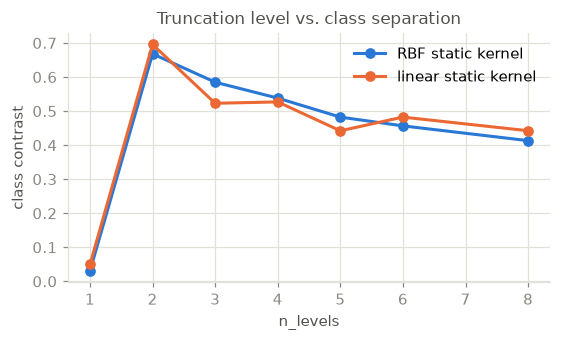

In [5]:
levels = [1, 2, 3, 4, 5, 6, 8]
contrast_rbf = [block_contrast(ksig.kernels.SignatureKernel(n_levels=n)(X), y) for n in levels]
contrast_lin = [block_contrast(
    ksig.kernels.SignatureKernel(n_levels=n, static_kernel=LinearKernel())(X), y) for n in levels]

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(levels, contrast_rbf, "-o", color=BLUE, lw=2, ms=6, label="RBF static kernel")
ax.plot(levels, contrast_lin, "-o", color=ORANGE, lw=2, ms=6, label="linear static kernel")
ax.set_xlabel("n_levels")
ax.set_ylabel("class contrast")
ax.set_title("Truncation level vs. class separation", fontsize=11, color="#52514e")
ax.legend(frameon=False)
fig.tight_layout()

## 3. Preprocessing

`ksig.preprocessing` has two scikit-learn transformers.

`SequenceAugmentor` applies the standard path augmentations: normalisation, a
lead-lag transform (doubles the length and the channels), a time channel and a
basepoint at the origin. Time augmentation makes the signature sensitive to the
*speed* of the path — use it when the parameterisation carries information, drop
it when it does not.

⚠️ `SequenceAugmentor.transform` divides the input array in place when
`normalize=True`; pass a copy if you still need the raw data.

In [6]:
augmentor = SequenceAugmentor(add_time=True, lead_lag=True, basepoint=True, normalize=True)
X_aug = augmentor.fit_transform(X.copy())
print(f"{X.shape} -> {X_aug.shape}  (lead-lag doubles length & channels, "
      f"+1 time channel, +1 basepoint step)")
print("class contrast after augmentation:", round(block_contrast(sig_kernel(X_aug), y), 3))

(40, 50, 2) -> (40, 100, 5)  (lead-lag doubles length & channels, +1 time channel, +1 basepoint step)
class contrast after augmentation: 0.517


`SequenceTabulator` takes a *list* of sequences of different lengths (optionally
containing `NaN` rows) and interpolates them onto a common grid, which is what you
need if your raw episodes are ragged.

In [7]:
ragged = [X[i, : rng.integers(20, 50)] for i in range(len(X))]
print("raw lengths:", sorted({len(s) for s in ragged}))

X_tab = SequenceTabulator(max_len=40).fit_transform(ragged)
print("tabulated:", X_tab.shape, "| class contrast:", round(block_contrast(sig_kernel(X_tab), y), 3))

raw lengths: [20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 34, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
tabulated: (40, 40, 2) | class contrast: 0.341


## 4. Reparameterisation invariance

The signature of a path is invariant to how the path is traversed in time — only
the geometric order of the curve matters. This is the property that makes the
kernel robust to irregular sampling.

Below, each path is re-sampled at 150 random increasing time points instead of the
original 60 evenly spaced ones. The signature kernel between the original and its
re-sampled twin stays near 1, and every re-sampled path retrieves its own original
as nearest neighbour. Note also that the two arrays have **different lengths** —
something a flattened static kernel cannot even compare without extra alignment.

(30, 60, 2) vs (30, 150, 2)
mean K(path, re-sampled path) = 0.9893
mean K(path, other path)      = 0.1896
nearest-neighbour retrieval    = 100.0%


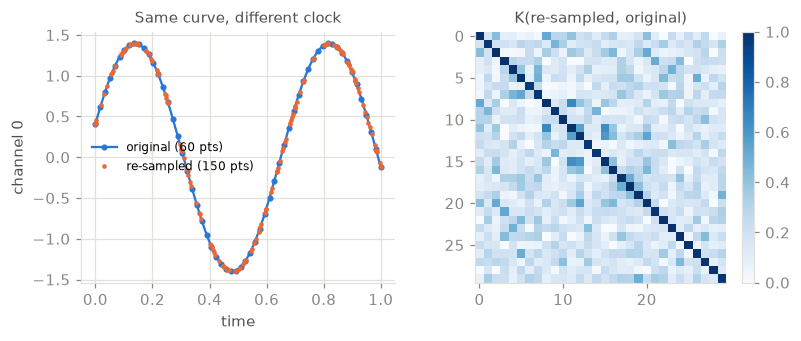

In [8]:
def wiggly(n, length=60, rng=rng):
    """`n` random 2D Lissajous-like paths."""
    u = np.linspace(0, 1, length)
    freq = rng.uniform(1, 3, (n, 2))
    phase = rng.uniform(0, 2 * np.pi, (n, 2))
    amp = rng.uniform(0.5, 1.5, (n, 2))
    return np.stack(
        [amp[:, c, None] * np.sin(2 * np.pi * freq[:, c, None] * u[None] + phase[:, c, None])
         for c in range(2)], axis=-1)


P = wiggly(30)
grid = np.linspace(0, 1, P.shape[1])
new_times = np.sort(np.concatenate([[0.0], rng.uniform(0, 1, 148), [1.0]]))
P_resampled = np.stack([
    np.stack([np.interp(new_times, grid, P[i, :, c]) for c in range(2)], axis=-1)
    for i in range(len(P))])

K_pair = sig_kernel(P_resampled, P)
top1 = (K_pair.argmax(axis=1) == np.arange(len(P))).mean()
print(f"{P.shape} vs {P_resampled.shape}")
print(f"mean K(path, re-sampled path) = {np.diag(K_pair).mean():.4f}")
print(f"mean K(path, other path)      = {K_pair[~np.eye(len(P), dtype=bool)].mean():.4f}")
print(f"nearest-neighbour retrieval    = {top1:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
axes[0].plot(grid, P[0, :, 0], "-o", ms=3, color=BLUE, label="original (60 pts)")
axes[0].plot(new_times, P_resampled[0, :, 0], ".", ms=4, color=ORANGE, label="re-sampled (150 pts)")
axes[0].set_xlabel("time")
axes[0].set_ylabel("channel 0")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title("Same curve, different clock", fontsize=10, color="#52514e")
im = axes[1].imshow(K_pair, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("K(re-sampled, original)", fontsize=10, color="#52514e")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.tight_layout()

## 5. Classification with a precomputed kernel

Toy dataset B: two channels, each with one Gaussian bump at a random time. The
label is simply **which channel bumps first** — pure ordering information. Every
sequence is observed on its own randomly warped clock, so the bump *positions in
index space* are uninformative on their own.

(80, 60, 2) (200, 60, 2)


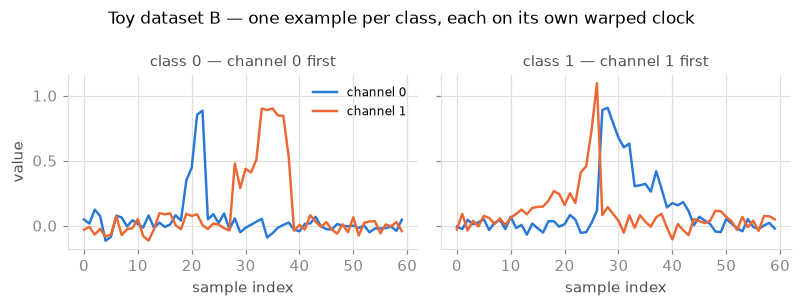

In [9]:
def random_warp(length, shape=0.3, rng=rng):
    """A random increasing reparameterisation of [0, 1] on `length` points."""
    increments = rng.gamma(shape, 1.0, size=length - 1)
    steps = np.concatenate([[0.0], np.cumsum(increments)])
    return steps / steps[-1]


def bump_dataset(n_per_class, length=60, noise=0.05, min_gap=0.1, warped=True, rng=rng):
    X = np.empty((2 * n_per_class, length, 2))
    y = np.repeat([0.0, 1.0], n_per_class)
    for i in range(2 * n_per_class):
        clock = random_warp(length, rng=rng) if warped else np.linspace(0, 1, length)
        while True:
            t0, t1 = rng.uniform(0.15, 0.85, 2)
            if abs(t0 - t1) > min_gap:
                break
        if (t0 > t1) != bool(y[i]):  # class 0: channel 0 bumps first
            t0, t1 = t1, t0
        width = rng.uniform(0.04, 0.09, 2)
        amp = rng.uniform(0.8, 1.2, 2)
        X[i, :, 0] = amp[0] * np.exp(-((clock - t0) ** 2) / (2 * width[0] ** 2))
        X[i, :, 1] = amp[1] * np.exp(-((clock - t1) ** 2) / (2 * width[1] ** 2))
    X += noise * rng.standard_normal(X.shape)
    perm = rng.permutation(len(X))
    return X[perm], y[perm]


X_train, y_train = bump_dataset(40)
X_test, y_test = bump_dataset(100)
print(X_train.shape, X_test.shape)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.8), sharey=True)
for ax, cls, name in zip(axes, [0, 1], ["class 0 — channel 0 first", "class 1 — channel 1 first"]):
    example = X_train[y_train == cls][0]
    ax.plot(example[:, 0], color=BLUE, lw=1.6, label="channel 0")
    ax.plot(example[:, 1], color=ORANGE, lw=1.6, label="channel 1")
    ax.set_title(name, fontsize=10, color="#52514e")
    ax.set_xlabel("sample index")
axes[0].set_ylabel("value")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Toy dataset B — one example per class, each on its own warped clock", fontsize=11)
fig.tight_layout()

`ksig.models` wraps this into `PrecomputedKernelSVC`, but that module imports
`cuml`, which is not in this environment — so here is the same thing with plain
scikit-learn: precompute the Gram matrices and hand them to an `SVC` with
`kernel="precomputed"`. The test-time matrix is `K(X_test, X_train)`.

RBF on flattened paths           0.905
Signature n_levels=2             0.765
Signature n_levels=3             0.730
Signature n_levels=4             0.980
Signature n_levels=6             0.990


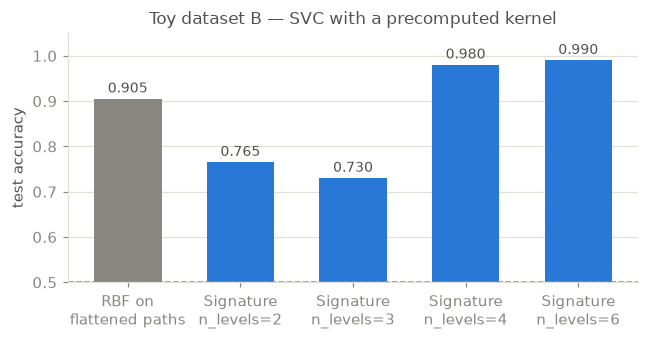

In [10]:
def svc_accuracy(kernel, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(SVC(kernel="precomputed"), {"C": [0.1, 1, 10, 100, 1000]}, cv=5)
    grid.fit(kernel(X_train), y_train)
    return grid.score(kernel(X_test, X_train), y_test)


bandwidth = float(np.median(pdist(X_train.reshape(len(X_train), -1))))  # median heuristic
scores = {"RBF on\nflattened paths": svc_accuracy(
    RBFKernel(bandwidth=bandwidth), X_train, y_train, X_test, y_test)}
for n in [2, 3, 4, 6]:
    scores[f"Signature\nn_levels={n}"] = svc_accuracy(
        ksig.kernels.SignatureKernel(n_levels=n), X_train, y_train, X_test, y_test)

for name, score in scores.items():
    print(f"{name.replace(chr(10), ' '):32s} {score:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
colors = [MUTED] + [BLUE] * (len(scores) - 1)
bars = ax.bar(list(scores), list(scores.values()), color=colors, width=0.6)
ax.bar_label(bars, fmt="%.3f", fontsize=9, color="#52514e", padding=2)
ax.set_ylim(0.5, 1.05)
ax.axhline(0.5, color=MUTED, lw=1, ls="--")
ax.set_ylabel("test accuracy")
ax.set_title("Toy dataset B — SVC with a precomputed kernel", fontsize=11, color="#52514e")
ax.grid(axis="x", visible=False)
fig.tight_layout()

The signature kernel needs enough levels to reach the term that encodes the
ordering — below `n_levels=4` it is *worse* than the flat baseline here, above it
it is close to perfect. The truncation level is the hyperparameter to tune first.

## 6. Low-rank signature features

The full kernel materialises a `[n_X, n_Y, length, length]` tensor of pointwise
static-kernel evaluations, so both time and memory grow as O(n² ℓ²). For larger
datasets `SignatureFeatures` builds an explicit **feature map** instead: random
Fourier features approximate the static kernel, and a tensor random projection
keeps the tensor products low-dimensional. It is a scikit-learn transformer —
`fit` then `transform` — and the resulting features satisfy `K ≈ P @ P.T`.

features: (40, 1001) | K ≈ P @ P.T max error: 0.1871
correlation with the exact Gram: 0.9881
calling the object directly gives the same matrix: True


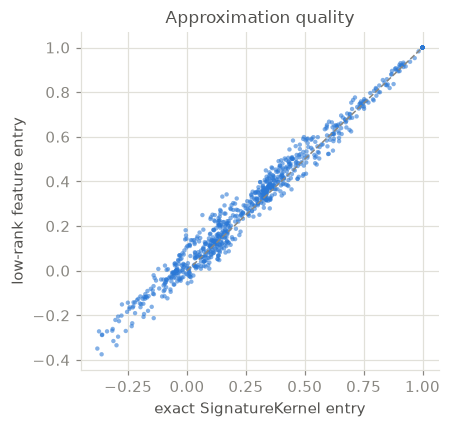

In [11]:
sig_features = ksig.kernels.SignatureFeatures(
    n_levels=5,
    static_features=RandomFourierFeatures(n_components=100, bandwidth=1.0, random_state=0),
    projection=TensorizedRandomProjection(n_components=200, random_state=0),
)
sig_features.fit(X)
P_feat = sig_features.transform(X)
K_lowrank = P_feat @ P_feat.T

print("features:", P_feat.shape, "| K ≈ P @ P.T max error:", np.abs(K_lowrank - K_sig).max().round(4))
print("correlation with the exact Gram:", np.corrcoef(K_lowrank.ravel(), K_sig.ravel())[0, 1].round(4))
print("calling the object directly gives the same matrix:",
      np.allclose(sig_features(X), K_lowrank))

fig, ax = plt.subplots(figsize=(4.2, 4))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.scatter(K_sig.ravel(), K_lowrank.ravel(), s=8, alpha=0.35, color=BLUE, edgecolor="none")
ax.set_xlabel("exact SignatureKernel entry")
ax.set_ylabel("low-rank feature entry")
ax.set_title("Approximation quality", fontsize=11, color="#52514e")
fig.tight_layout()

With an explicit feature map you can drop the kernel machinery entirely and use a
linear model, which is what makes this scale.

In [12]:
sig_features.fit(X_train)
F_train, F_test = sig_features.transform(X_train), sig_features.transform(X_test)
linear = GridSearchCV(LinearSVC(), {"C": [0.1, 1, 10, 100]}, cv=5).fit(F_train, y_train)
print(f"LinearSVC on {F_train.shape[1]}-dim signature features: {linear.score(F_test, y_test):.3f}")

LinearSVC on 1001-dim signature features: 0.990


full kernel          n=100: 0.014s n=200: 0.056s n=400: 0.222s n=800: 0.888s
low-rank features    n=100: 0.005s n=200: 0.009s n=400: 0.016s n=800: 0.031s


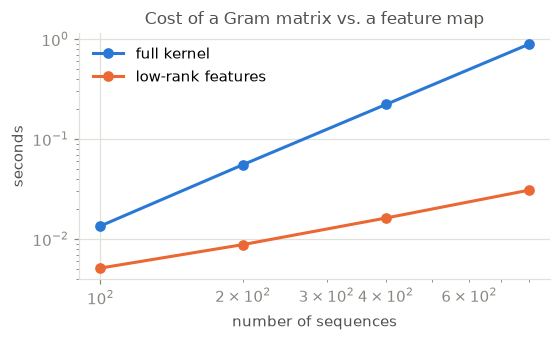

In [13]:
sizes = [100, 200, 400, 800]
timings = {"full kernel": [], "low-rank features": []}
for n in sizes:
    Z = np.concatenate([loops(n // 2, length=32, sign=+1), loops(n // 2, length=32, sign=-1)])
    t0 = time.perf_counter()
    sig_kernel(Z, return_on_gpu=True)
    cp.cuda.Stream.null.synchronize()
    t1 = time.perf_counter()
    sig_features.fit(Z).transform(Z, return_on_gpu=True)
    cp.cuda.Stream.null.synchronize()
    timings["full kernel"].append(t1 - t0)
    timings["low-rank features"].append(time.perf_counter() - t1)

fig, ax = plt.subplots(figsize=(5.2, 3.2))
for (name, ts), color in zip(timings.items(), [BLUE, ORANGE]):
    ax.plot(sizes, ts, "-o", color=color, lw=2, ms=6, label=name)
    print(f"{name:20s}", " ".join(f"n={n}: {t:.3f}s" for n, t in zip(sizes, ts)))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of sequences")
ax.set_ylabel("seconds")
ax.set_title("Cost of a Gram matrix vs. a feature map", fontsize=11, color="#52514e")
ax.legend(frameon=False)
fig.tight_layout()

## 7. The rest of the zoo

* `SignaturePDEKernel` — the *untruncated* signature kernel of Salvi et al. (2021),
  computed by solving a Goursat PDE. No `n_levels` to choose.
* `GlobalAlignmentKernel` — the classic soft-DTW-style alignment kernel, computed
  in log space, for comparison.
* `RandomWarpingSeries` — a cheap random-feature sequence embedding, useful as a
  baseline.

RandomWarpingSeries feature shape: (40, 64)


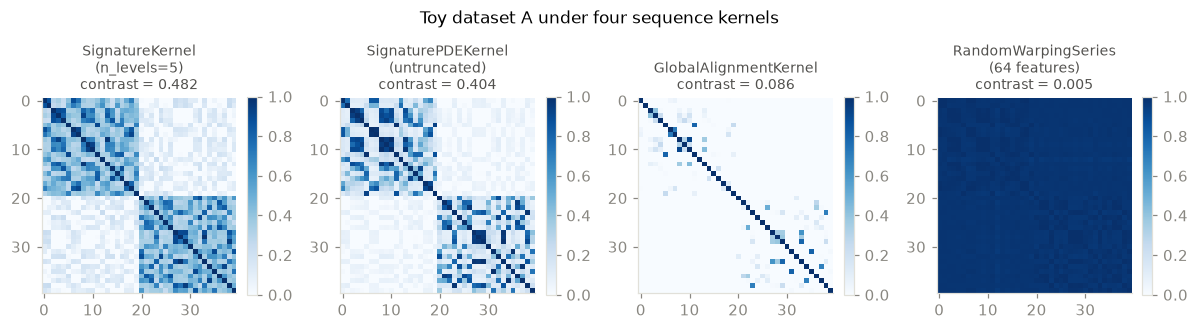

In [14]:
pde_kernel = ksig.kernels.SignaturePDEKernel(static_kernel=RBFKernel(bandwidth=1.0))
gak = ksig.kernels.GlobalAlignmentKernel(static_kernel=RBFKernel(bandwidth=1.0))
rws = ksig.kernels.RandomWarpingSeries(n_components=64, max_warp=16, random_state=0).fit(X)

grams = {
    "SignatureKernel\n(n_levels=5)": K_sig,
    "SignaturePDEKernel\n(untruncated)": pde_kernel(X),
    "GlobalAlignmentKernel": gak(X),
    "RandomWarpingSeries\n(64 features)": rws(X),
}

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, (name, K) in zip(axes, grams.items()):
    im = ax.imshow(K, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{name}\ncontrast = {block_contrast(K, y):.3f}", fontsize=9, color="#52514e")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Toy dataset A under four sequence kernels", fontsize=11)
fig.tight_layout()

print("RandomWarpingSeries feature shape:", rws.transform(X).shape)

The PDE kernel recovers the same block structure without a truncation level to
tune. The global alignment kernel is again near-diagonal here — like the flat RBF
it is dominated by the random phase — and `RandomWarpingSeries` at these settings
maps every loop to almost the same feature vector (all similarities ≈ 1), so it
separates nothing on this dataset. Both are worth re-tuning before writing them
off, but they illustrate that "a sequence kernel" is not automatically the right
sequence kernel.

## 8. Notes and gotchas

* **GPU only.** `ksig` imports `cupy` at module level; there is no CPU fallback.
  Keep large Gram matrices on the device with `return_on_gpu=True`.
* **Memory.** The full kernel builds a `[n_X, n_Y, ℓ_X, ℓ_Y]` array of static-kernel
  evaluations — 800 sequences of length 60 in float64 is already ~18 GB. Subsample
  the time axis, use `float32`, batch the Gram matrix, or switch to
  `SignatureFeatures`.
* **`ksig.models`** (`PrecomputedKernelSVC`, `PrecomputedFeatureLinSVC`) imports
  `cuml`, which is not installed here — the package `__init__` fails, so use
  scikit-learn with `kernel="precomputed"` as above.
* **`SequenceAugmentor` mutates its input** in place when `normalize=True`.
* **`normalize=True`** (the default) gives `K(x, x) = 1` and makes kernel values
  comparable across paths of different scale; turn it off if you want the raw
  signature inner product.
* **Static kernel bandwidth matters** as much as `n_levels` — scale your channels
  or tune it, e.g. with the median heuristic.
* `ndim == 2` inputs are interpreted as univariate sequences; pass `n_features`
  explicitly if you feed flattened multivariate arrays.